# Program and Version Explorer (DuckDB)

This notebook loads data from the dashboard DuckDB and visualizes `program_id` and `version` coverage.

It shows:
- event counts by `(program_id, version)`
- top programs by total events
- a heatmap-like matrix of program/version counts

In [5]:
from pathlib import Path

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Resolve database path robustly whether notebook is run from repo root or notebooks/
candidates = [
    Path("data/dashboard.db"),
    Path("../data/dashboard.db"),
]

db_path = next((p for p in candidates if p.exists()), None)
if db_path is None:
    raise FileNotFoundError("Could not find dashboard.db in data/ or ../data/")

print(f"Using database: {db_path.resolve()}")

con = duckdb.connect(str(db_path), read_only=True)

tables = con.execute("SHOW TABLES").fetchdf()
tables

Using database: /data/home/tkodippili/Desktop/localTest_Analysis_DashboardV3/Dashboard/data/dashboard.db


,name
0,_schema_metadata
1,audit_log
2,dim_channel_map
3,dim_event
4,dim_program
5,event_access_log
6,measurements_lttb
7,measurements_raw
8,saved_filters
9,sessions


In [ ]:
# Pull program/version distribution from dim_event
query = """
SELECT
    program_id,
    version,
    COUNT(*) AS event_count,
    SUM(CASE WHEN maturity IN ('Approved', 'Obsolete') THEN 1 ELSE 0 END) AS baseline_events,
    SUM(CASE WHEN maturity = 'Pending' THEN 1 ELSE 0 END) AS new_data_events
FROM dim_event
WHERE COALESCE(is_deleted, FALSE) = FALSE
GROUP BY program_id, version
ORDER BY program_id, version
"""

df = con.execute(query).fetchdf()

print(f"Rows: {len(df)}")
df.head(20)

Rows: 1


,program_id,version,event_count,baseline_events,new_data_events
0,13998,v35,34,34.0,0.0


## Plot all event LTTB curves for one version

Set `target_version` (and optional `target_program_id`) below, then run the cells.

This will:
- load all LTTB points for matching events
- group by `plot_key`
- draw all event curves per plot key

Version: v35
Program filter: None
Unique events: 34
Plot keys: 8
Total raw points: 31,838,208
Total LTTB points: 3,793,664


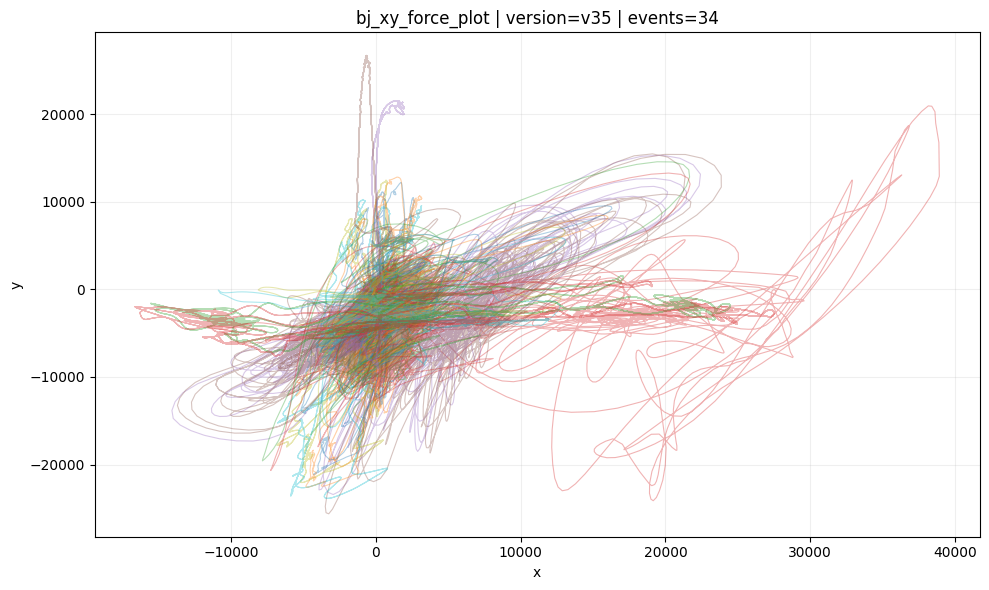

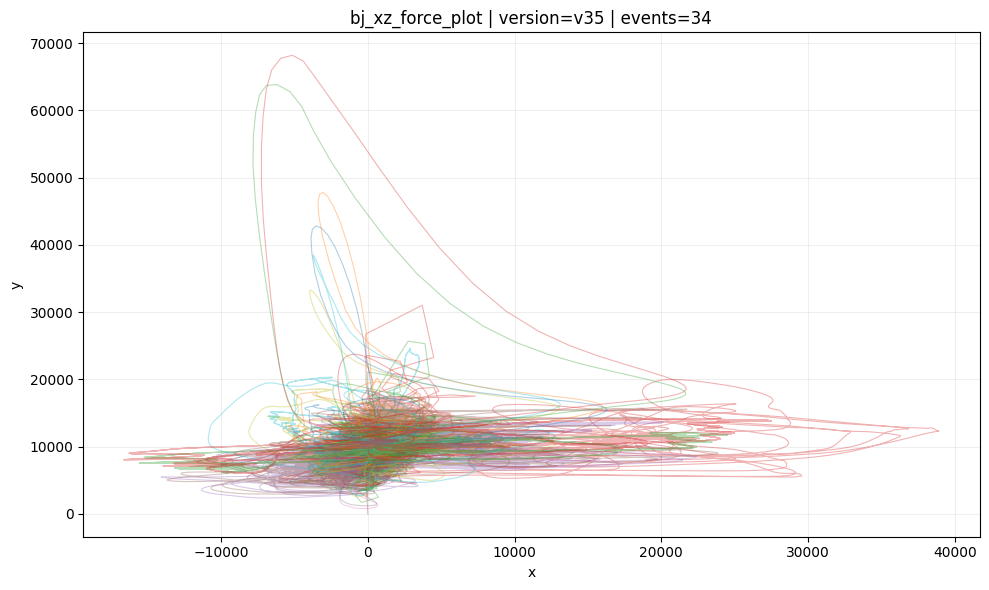

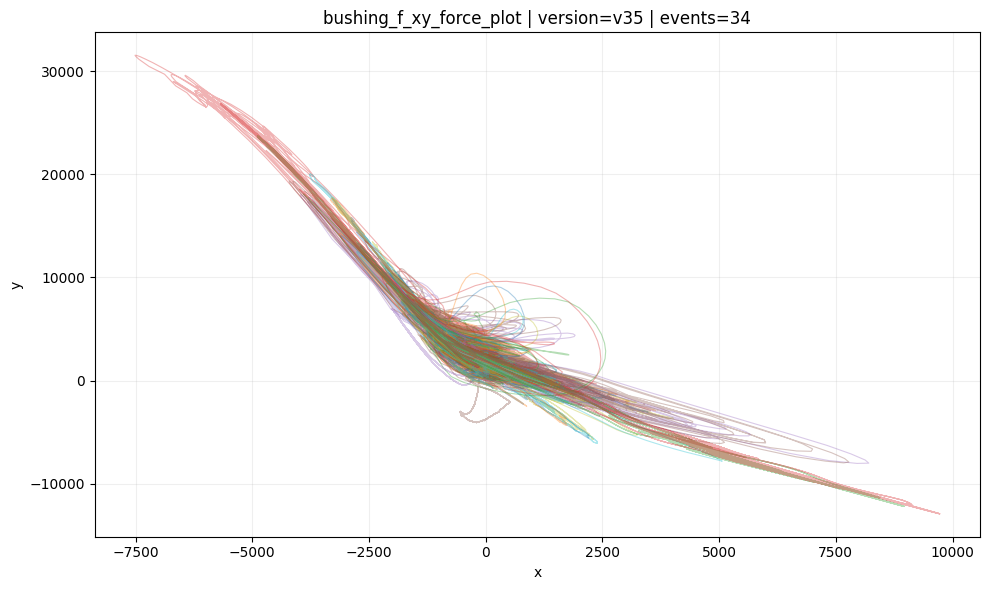

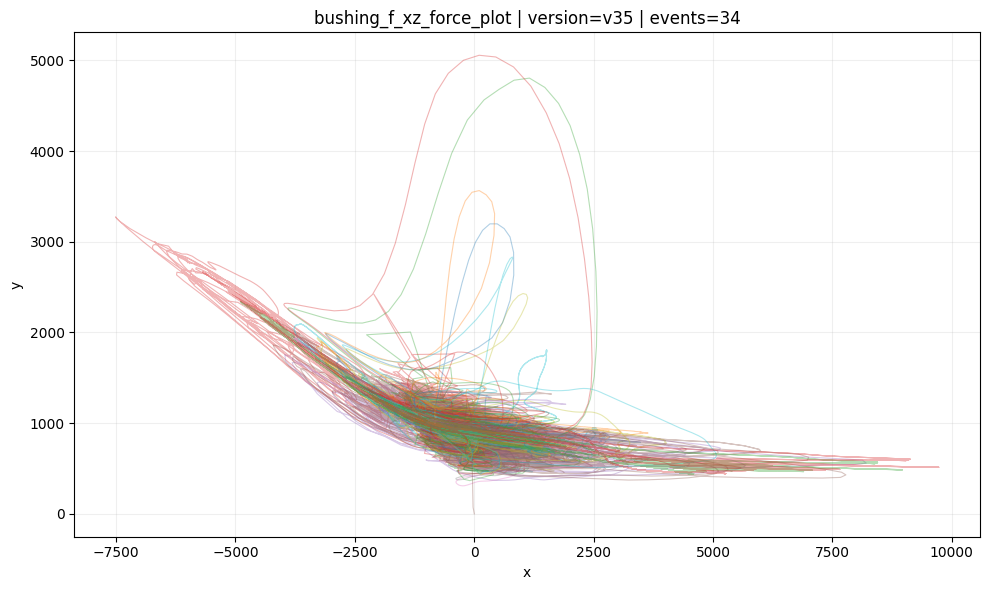

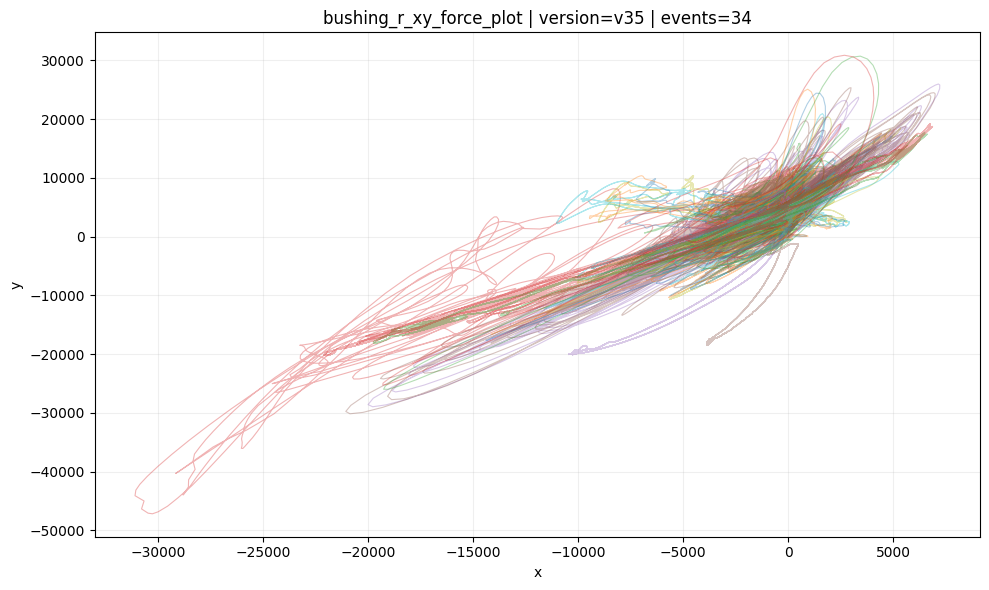

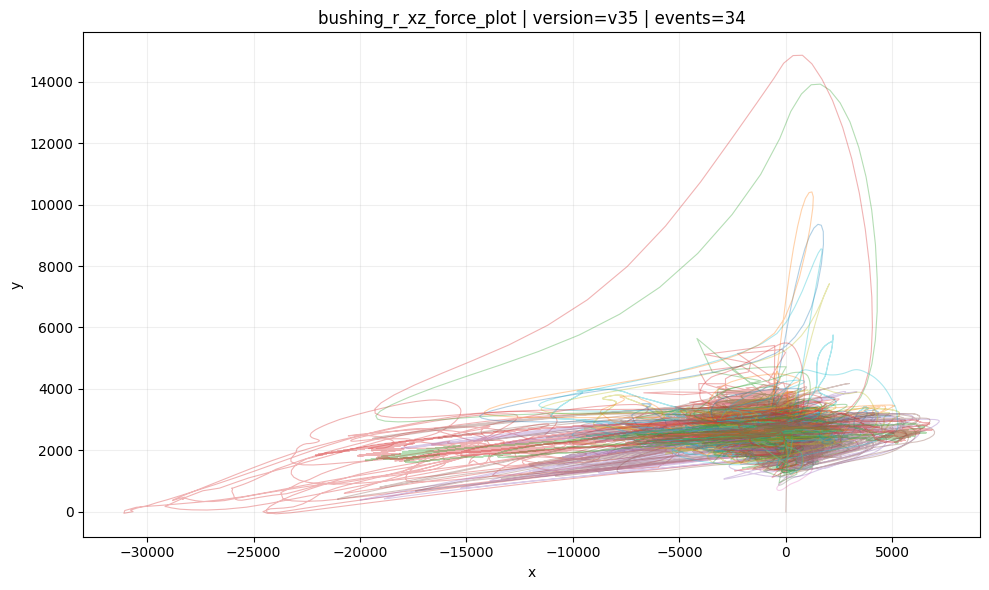

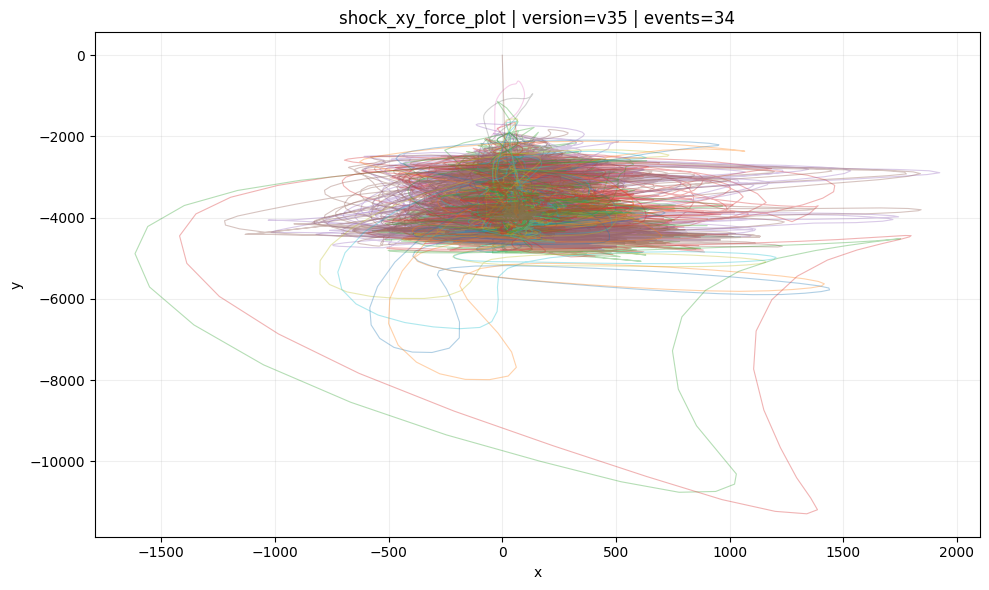

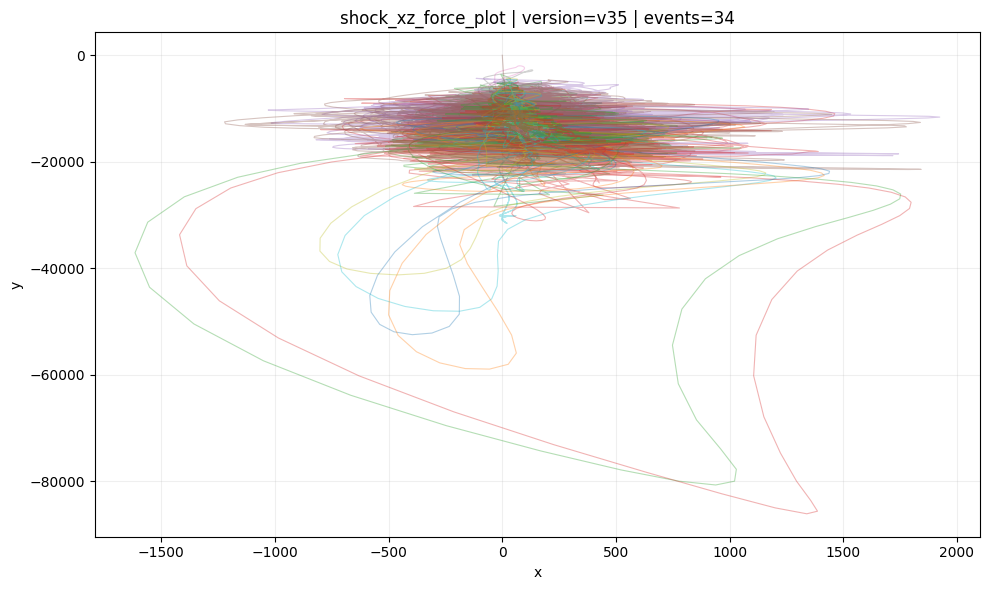

In [7]:
# Parameters
# Example: target_version = 'v35'
target_version = 'v35'

# Optional filter. Set to None to include all programs for this version.
target_program_id = None

# Optional limit to reduce clutter during exploration. Set None for all events.
max_events = None

base_query = """
SELECT
    e.event_id,
    e.program_id,
    e.version,
    l.plot_key,
    l.x,
    l.y
FROM measurements_lttb l
JOIN dim_event e ON e.event_id = l.event_id
WHERE COALESCE(e.is_deleted, FALSE) = FALSE
  AND e.version = ?
"""

params = [target_version]
if target_program_id is not None:
    base_query += " AND e.program_id = ?"
    params.append(target_program_id)

base_query += " ORDER BY l.plot_key, e.event_id, l.id"

lttb_df = con.execute(base_query, params).fetchdf()

if lttb_df.empty:
    print('No LTTB data found for the selected version/program filters.')
else:
    events = lttb_df[['event_id', 'program_id']].drop_duplicates()
    if max_events is not None:
        keep_event_ids = set(events.head(max_events)['event_id'])
        lttb_df = lttb_df[lttb_df['event_id'].isin(keep_event_ids)].copy()

    event_ids = lttb_df['event_id'].drop_duplicates().tolist()
    raw_point_count = 0
    if event_ids:
        placeholders = ", ".join(["?"] * len(event_ids))
        raw_count_query = f"SELECT COUNT(*) FROM measurements_raw WHERE event_id IN ({placeholders})"
        raw_point_count = int(con.execute(raw_count_query, event_ids).fetchone()[0])

    print(f"Version: {target_version}")
    print(f"Program filter: {target_program_id}")
    print(f"Unique events: {lttb_df['event_id'].nunique()}")
    print(f"Plot keys: {lttb_df['plot_key'].nunique()}")
    print(f"Total raw points: {raw_point_count:,}")
    print(f"Total LTTB points: {len(lttb_df):,}")

    plot_keys = lttb_df['plot_key'].drop_duplicates().tolist()
    n_plots = len(plot_keys)

    # One figure per plot key keeps each chart readable when many curves exist.
    for plot_key in plot_keys:
        subset = lttb_df[lttb_df['plot_key'] == plot_key]

        plt.figure(figsize=(10, 6))
        for event_id, grp in subset.groupby('event_id', sort=False):
            plt.plot(grp['x'].to_numpy(), grp['y'].to_numpy(), linewidth=0.8, alpha=0.35)

        plt.title(f"{plot_key} | version={target_version} | events={subset['event_id'].nunique()}")
        plt.xlabel('x')
        plt.ylabel('y')
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

In [8]:
# Close the DuckDB connection when finished with notebook work.
if 'con' in globals() and con is not None:
    con.close()
    con = None
    print('Connection closed.')
else:
    print('No active connection found.')

Connection closed.
